<a href="https://colab.research.google.com/github/Subah-Zarin/Wall-Decoration-Pattern-Analysis-/blob/main/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Random seed configured


✅ Google authentication completed

🔍 Checking Google Drive source folder...


✅ Source folder found:
Wall decoration images
Folder ID: 1R3In2Qz7thxV5XkDaRJRkSwQnAemJLzj

✅ Local directories ready

DRIVE CONTENT
Total files: 210
Supported image files: 206

🔄 Downloading images from Google Drive...
Downloaded 25/206
Downloaded 50/206
Downloaded 75/206
Downloaded 100/206
Downloaded 125/206
Downloaded 150/206
Downloaded 175/206
Downloaded 200/206
Downloaded 206/206
✅ Image download completed

LOCAL IMAGE INDEX
Downloaded image files: 206
Unique image IDs: 206

✅ Google Sheet connected
Spreadsheet: Softcomp Annotation
Worksheet: Sheet1

GOOGLE SHEET
Total records: 206
Columns: ['image_id', 'wall_type', 'indoor', 'description_en', 'description_bn', 'color_idea']
✅ Required columns verified
✅ Sheet data cleaned

DUPLICATE IMAGE IDs IN SHEET
Duplicate ID groups: 0
✅ No duplicate image IDs

Duplicate IDs in Drive: 0

MISSING IMAGE CHECK
Missing images: 1
Missing IDs:
 - image_067.jpg

🔍 Checking image integrity...
Corrupted images: 1

VALID DATASET
Sheet records: 206
Mat

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating multilingual embeddings...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Semantic groups: 85
✅ group_review.csv saved
Largest group: 74
Groups with multiple images: 19

TRAIN / VALIDATION / TEST SPLIT

Total: 204
Train: 171
Validation: 8
Test: 25

IMAGE-ID LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0
✅ NO IMAGE-ID LEAKAGE

GROUP LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0
✅ NO GROUP LEAKAGE

✅ train.csv saved
✅ validation.csv saved
✅ test.csv saved

✅ Image preprocessing configured
✅ PyTorch datasets created
Train dataset: 171
Validation dataset: 8
Test dataset: 25


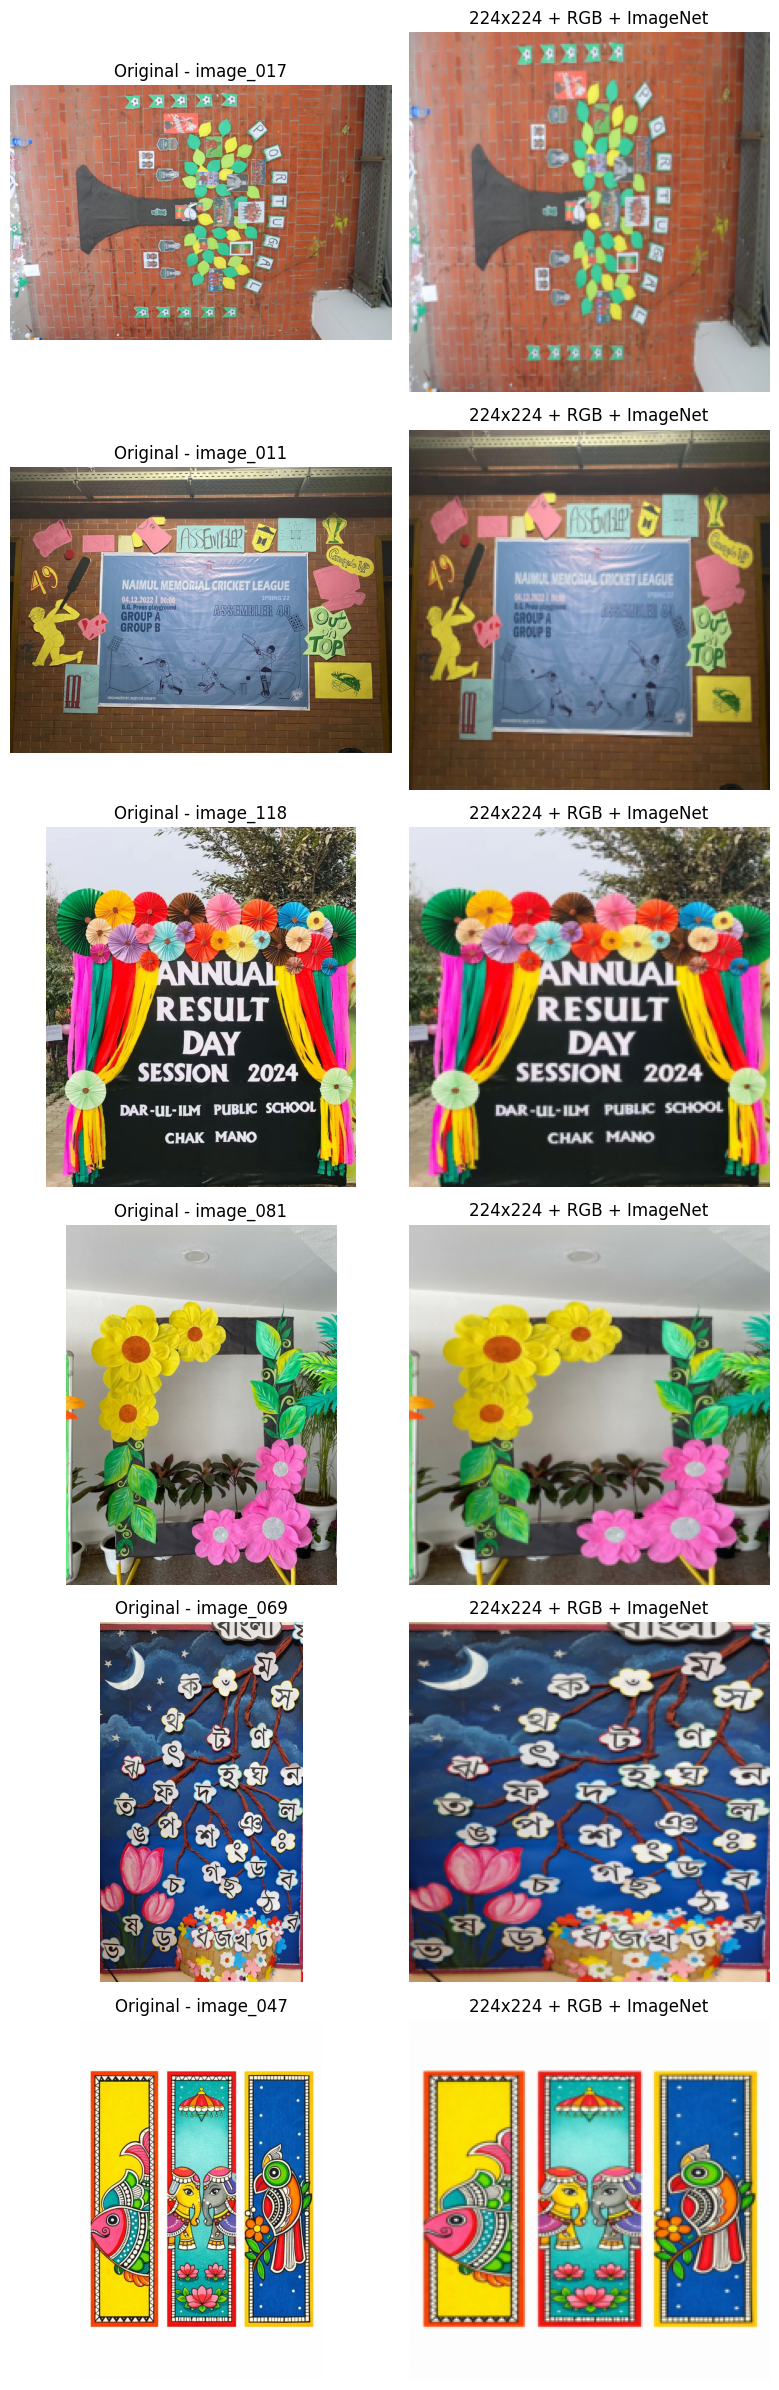

✅ before_after.png saved


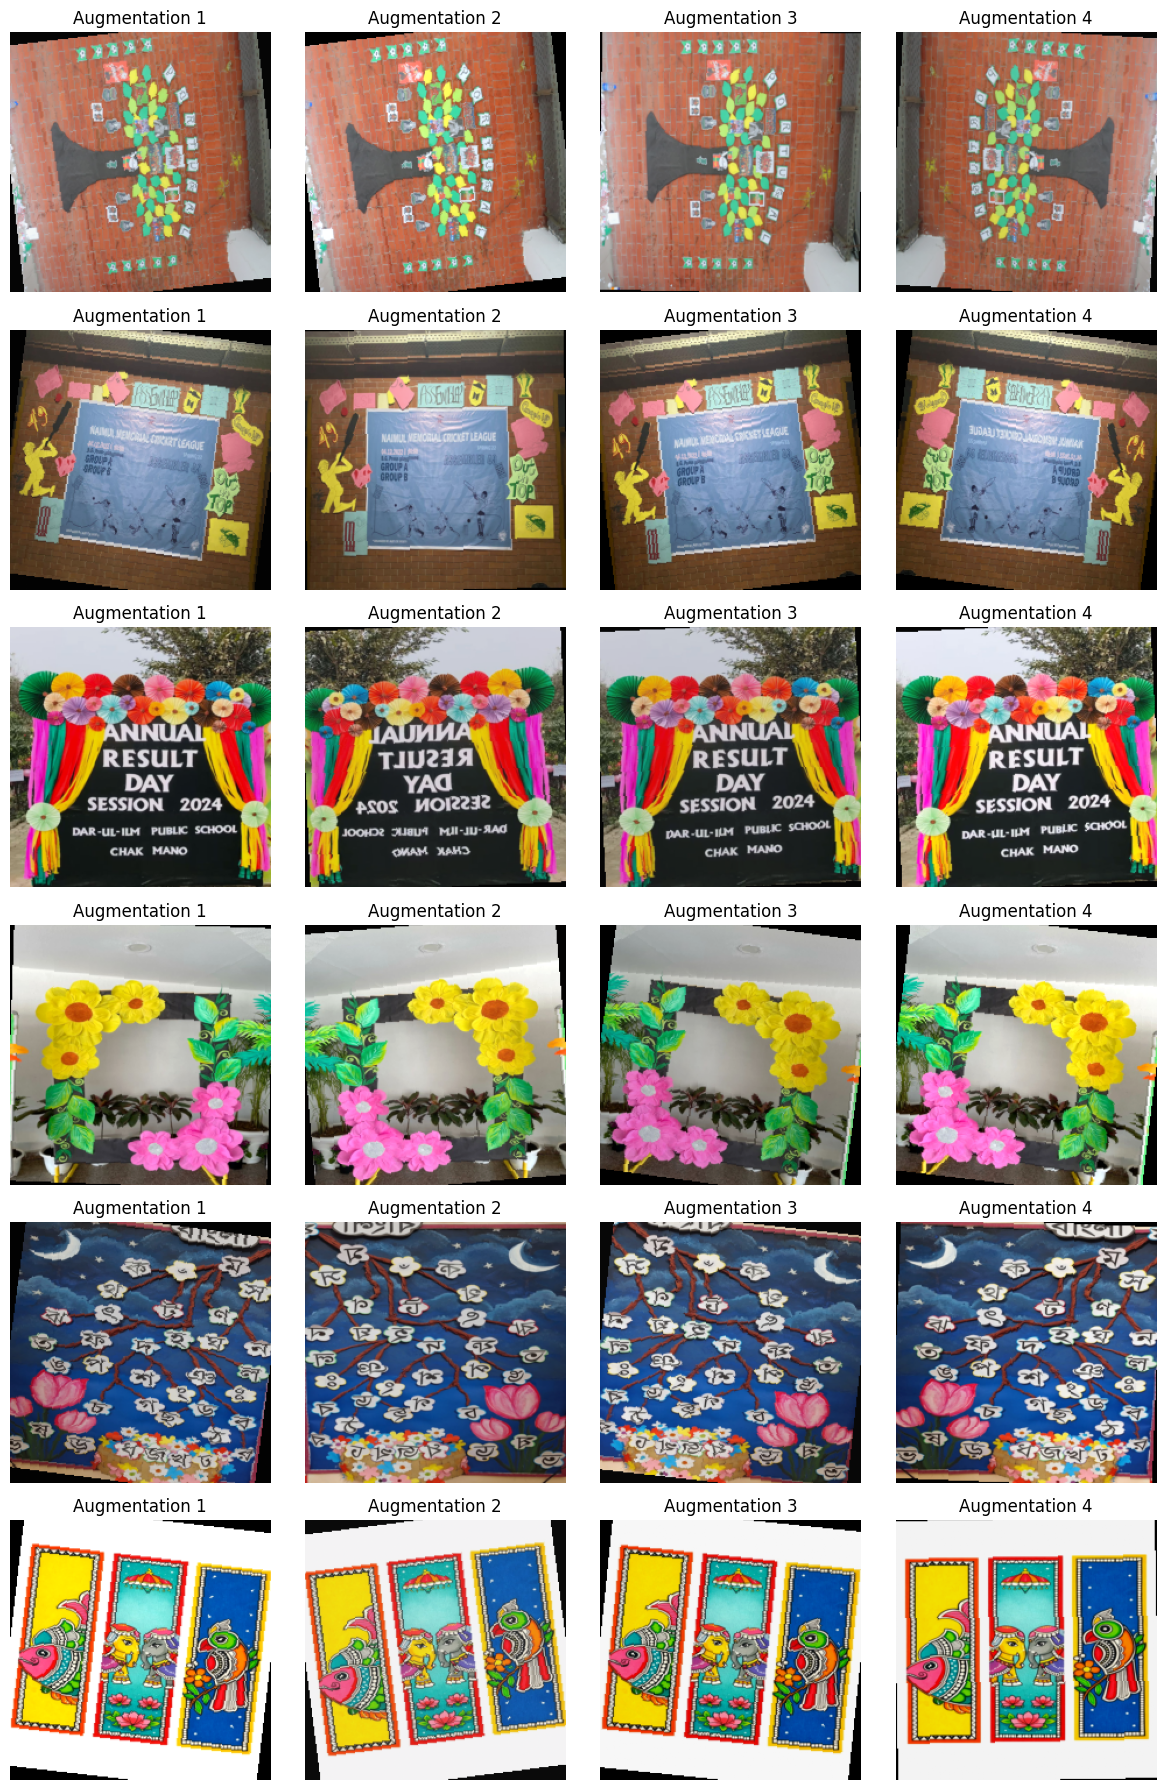

✅ augmentation_examples.png saved

WALL TYPE DISTRIBUTION
wall_type
painted_wall      118
bulletin_board     29
brick_wall         27
backdrop_board     19
wooden_wall        11
Name: count, dtype: int64

UPLOADING OUTPUTS TO GOOGLE DRIVE
✅ New output folder created
Output folder: Campus_Wall_Preprocessing
Output folder ID: 1pExO184VCpaXx8FmEgUA5aUxQ7h1s3Oy
✅ Uploaded: augmentation_examples.png
✅ Uploaded: before_after.png
✅ Uploaded: corrupted_images.csv
✅ Uploaded: dataset_statistics.json
✅ Uploaded: duplicate_image_ids.csv
✅ Uploaded: exact_duplicate_groups.json
✅ Uploaded: group_review.csv
✅ Uploaded: group_sizes.csv
✅ Uploaded: missing_images.csv
✅ Uploaded: near_duplicate_images.csv
✅ Uploaded: preprocessing_config.json
✅ Uploaded: preprocessing_note.txt
✅ Uploaded: test.csv
✅ Uploaded: train.csv
✅ Uploaded: validation.csv
✅ Uploaded: wall_type_distribution.csv


🎉 CAMPUS WALL DECORATION PIPELINE COMPLETED

SOURCE DRIVE FOLDER:
Wall decoration images
Folder ID: 1R3In2Qz7thxV5XkDa

In [11]:
# ============================================================
# CAMPUS WALL DECORATION
# COMPLETE ONE-CELL PREPROCESSING PIPELINE
#
# IMPORTANT:
#   - Google Drive mount is NOT used
#   - Source folder is accessed using Drive Folder ID
#   - Original Drive images are NOT modified
#   - Original Google Sheet is NOT modified
# ============================================================


# ============================================================
# 1. INSTALL PACKAGES
# ============================================================

!pip -q install \
    pandas \
    numpy \
    pillow \
    matplotlib \
    scikit-learn \
    torch \
    torchvision \
    sentence-transformers \
    gspread \
    google-api-python-client \
    google-auth \
    imagehash


# ============================================================
# 2. IMPORTS
# ============================================================

import os
import io
import json
import random
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = False

import imagehash

import torch
from torch.utils.data import Dataset

from torchvision import transforms

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")


# ============================================================
# 3. USER SETTINGS
# ============================================================

# ------------------------------------------------------------
# Google Sheet
# ------------------------------------------------------------

GOOGLE_SHEET_NAME = "Softcomp Annotation"
SHEET_NAME = "Sheet1"


# ------------------------------------------------------------
# YOUR GOOGLE DRIVE FOLDER
# ------------------------------------------------------------
#
# From the link you provided:
#
# https://drive.google.com/drive/folders/
# 1R3In2Qz7thxV5XkDaRJRkSwQnAemJLzj
#
# ------------------------------------------------------------

DRIVE_FOLDER_ID = "1R3In2Qz7thxV5XkDaRJRkSwQnAemJLzj"


# ------------------------------------------------------------
# Local temporary image folder
# ------------------------------------------------------------

LOCAL_IMAGE_FOLDER = "/content/wall_decoration_images"


# ------------------------------------------------------------
# Local output folder
# ------------------------------------------------------------

LOCAL_OUTPUT_FOLDER = "/content/Campus_Wall_Preprocessing"


# ------------------------------------------------------------
# Google Drive output folder
# ------------------------------------------------------------

DRIVE_OUTPUT_FOLDER_NAME = "Campus_Wall_Preprocessing"


# ------------------------------------------------------------
# Dataset split
# ------------------------------------------------------------

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42


# ------------------------------------------------------------
# Description grouping
# ------------------------------------------------------------

DESCRIPTION_SIMILARITY_THRESHOLD = 0.80


# ------------------------------------------------------------
# Near duplicate threshold
# ------------------------------------------------------------

PHASH_DISTANCE_THRESHOLD = 5


# ------------------------------------------------------------
# Supported image types
# ------------------------------------------------------------

SUPPORTED_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}


# ------------------------------------------------------------
# Image preprocessing
# ------------------------------------------------------------

IMAGE_SIZE = (224, 224)


IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406
)


IMAGENET_STD = (
    0.229,
    0.224,
    0.225
)


MODEL_NAME = (
    "paraphrase-multilingual-MiniLM-L12-v2"
)


# ============================================================
# 4. RANDOM SEEDS
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


print("✅ Random seed configured")


# ============================================================
# 5. GOOGLE AUTHENTICATION
# ============================================================

from google.colab import auth

auth.authenticate_user()


import google.auth
import gspread

from googleapiclient.discovery import build

from googleapiclient.http import (
    MediaIoBaseDownload,
    MediaFileUpload
)


SCOPES = [

    "https://www.googleapis.com/auth/drive",

    "https://www.googleapis.com/auth/spreadsheets"

]


creds, _ = google.auth.default(
    scopes=SCOPES
)


gc = gspread.authorize(
    creds
)


# Drive API

drive_service = build(
    "drive",
    "v3",
    credentials=creds
)


print("✅ Google authentication completed")


# ============================================================
# 6. CHECK DRIVE SOURCE FOLDER
# ============================================================

print(
    "\n🔍 Checking Google Drive source folder..."
)


try:

    source_folder = drive_service.files().get(

        fileId=DRIVE_FOLDER_ID,

        fields="id,name,mimeType,parents"

    ).execute()


except Exception as e:

    raise RuntimeError(

        "\n❌ Could not access the Google Drive folder.\n\n"

        f"Folder ID:\n{DRIVE_FOLDER_ID}\n\n"

        "Make sure the folder is shared with the Google account "
        "you authenticated in Colab.\n\n"

        f"Google Drive error:\n{e}"

    )


if source_folder.get("mimeType") != "application/vnd.google-apps.folder":

    raise RuntimeError(

        "\n❌ The provided Drive ID is not a folder.\n\n"

        f"Name: {source_folder.get('name')}\n"

        f"ID: {DRIVE_FOLDER_ID}"

    )


print(
    "✅ Source folder found:"
)

print(
    source_folder.get("name")
)


print(
    "Folder ID:",
    DRIVE_FOLDER_ID
)


# ============================================================
# 7. PREPARE LOCAL DIRECTORIES
# ============================================================

os.makedirs(
    LOCAL_IMAGE_FOLDER,
    exist_ok=True
)


os.makedirs(
    LOCAL_OUTPUT_FOLDER,
    exist_ok=True
)


print(
    "\n✅ Local directories ready"
)


# ============================================================
# 8. RECURSIVELY LIST DRIVE FILES
# ============================================================

def list_drive_children(folder_id):

    """
    Recursively collect all files inside a Drive folder,
    including files in subfolders.
    """

    collected = []

    page_token = None


    while True:

        response = drive_service.files().list(

            q=(
                f"'{folder_id}' in parents "
                "and trashed = false"
            ),

            fields=(
                "nextPageToken,"
                "files("
                "id,"
                "name,"
                "mimeType,"
                "size,"
                "md5Checksum"
                ")"
            ),

            pageSize=1000,

            pageToken=page_token

        ).execute()


        items = response.get(
            "files",
            []
        )


        for item in items:

            if (
                item.get("mimeType")
                ==
                "application/vnd.google-apps.folder"
            ):

                collected.extend(

                    list_drive_children(
                        item["id"]
                    )

                )

            else:

                collected.append(
                    item
                )


        page_token = response.get(
            "nextPageToken"
        )


        if not page_token:

            break


    return collected


drive_files = list_drive_children(
    DRIVE_FOLDER_ID
)


print(
    "\n============================================"
)

print(
    "DRIVE CONTENT"
)

print(
    "============================================"
)

print(
    "Total files:",
    len(drive_files)
)


# ============================================================
# 9. FILTER IMAGE FILES
# ============================================================

image_files = []


for item in drive_files:

    filename = item.get(
        "name",
        ""
    )


    extension = (
        Path(filename)
        .suffix
        .lower()
    )


    if extension in SUPPORTED_EXTENSIONS:

        image_files.append(
            item
        )


print(
    "Supported image files:",
    len(image_files)
)


if len(image_files) == 0:

    raise RuntimeError(

        "\n❌ No JPG/JPEG/PNG/WEBP images found "
        "inside the provided Drive folder."

    )


# ============================================================
# 10. DOWNLOAD IMAGES TO LOCAL COLAB STORAGE
# ============================================================

print(
    "\n🔄 Downloading images from Google Drive..."
)


download_records = []


for counter, item in enumerate(
    image_files,
    start=1
):

    drive_file_id = item["id"]

    filename = item["name"]

    local_path = os.path.join(
        LOCAL_IMAGE_FOLDER,
        filename
    )


    try:

        request = drive_service.files().get_media(
            fileId=drive_file_id
        )


        with open(
            local_path,
            "wb"
        ) as file:

            downloader = MediaIoBaseDownload(
                file,
                request
            )


            done = False


            while not done:

                status, done = downloader.next_chunk()


        download_records.append({

            "drive_id":
                drive_file_id,

            "filename":
                filename,

            "local_path":
                local_path,

            "success":
                True

        })


    except Exception as e:

        print(
            f"⚠️ Download failed: {filename}"
        )

        print(
            str(e)
        )


    if (
        counter % 25 == 0
        or
        counter == len(image_files)
    ):

        print(
            f"Downloaded {counter}/{len(image_files)}"
        )


print(
    "✅ Image download completed"
)


# ============================================================
# 11. BUILD LOCAL IMAGE INDEX
# ============================================================

local_image_index = {}


local_image_files = []


for filename in os.listdir(
    LOCAL_IMAGE_FOLDER
):

    full_path = os.path.join(
        LOCAL_IMAGE_FOLDER,
        filename
    )


    if not os.path.isfile(
        full_path
    ):

        continue


    extension = (
        Path(filename)
        .suffix
        .lower()
    )


    if extension not in SUPPORTED_EXTENSIONS:

        continue


    image_id = (
        Path(filename)
        .stem
        .strip()
    )


    local_image_index.setdefault(
        image_id,
        []
    ).append(
        full_path
    )


    local_image_files.append(
        full_path
    )


print(
    "\n============================================"
)

print(
    "LOCAL IMAGE INDEX"
)

print(
    "============================================"
)

print(
    "Downloaded image files:",
    len(local_image_files)
)

print(
    "Unique image IDs:",
    len(local_image_index)
)


# ============================================================
# 12. CONNECT GOOGLE SHEET
# ============================================================

try:

    spreadsheet = gc.open(
        GOOGLE_SHEET_NAME
    )


    worksheet = spreadsheet.worksheet(
        SHEET_NAME
    )


except Exception as e:

    raise RuntimeError(

        "\n❌ Could not access Google Sheet.\n\n"

        f"Spreadsheet: {GOOGLE_SHEET_NAME}\n"

        f"Worksheet: {SHEET_NAME}\n\n"

        f"Error:\n{e}"

    )


print(
    "\n✅ Google Sheet connected"
)

print(
    "Spreadsheet:",
    spreadsheet.title
)

print(
    "Worksheet:",
    worksheet.title
)


# ============================================================
# 13. READ GOOGLE SHEET
# ============================================================

try:

    records = worksheet.get_all_records()

except Exception as e:

    raise RuntimeError(

        f"\n❌ Could not read Google Sheet:\n{e}"

    )


df = pd.DataFrame(
    records
)


if df.empty:

    raise ValueError(
        "\n❌ Google Sheet contains no data."
    )


df.columns = [

    str(column).strip()

    for column in df.columns

]


print(
    "\n============================================"
)

print(
    "GOOGLE SHEET"
)

print(
    "============================================"
)

print(
    "Total records:",
    len(df)
)

print(
    "Columns:",
    df.columns.tolist()
)


# ============================================================
# 14. REQUIRED COLUMNS
# ============================================================

REQUIRED_COLUMNS = [

    "image_id",

    "wall_type",

    "indoor",

    "description_en",

    "description_bn",

    "color_idea"

]


missing_columns = [

    column

    for column in REQUIRED_COLUMNS

    if column not in df.columns

]


if missing_columns:

    raise ValueError(

        "\n❌ Missing required columns:\n"

        +

        "\n".join(

            f"- {column}"

            for column in missing_columns

        )

    )


print(
    "✅ Required columns verified"
)


# ============================================================
# 15. CLEAN SHEET DATA
# ============================================================

df["image_id"] = (

    df["image_id"]

    .fillna("")

    .astype(str)

    .str.strip()

)


TEXT_COLUMNS = [

    "wall_type",

    "indoor",

    "description_en",

    "description_bn",

    "color_idea"

]


for column in TEXT_COLUMNS:

    df[column] = (

        df[column]

        .fillna("")

        .astype(str)

        .str.strip()

    )


# Empty IDs

empty_id_df = df[
    df["image_id"] == ""
].copy()


if not empty_id_df.empty:

    empty_id_df.to_csv(

        os.path.join(
            LOCAL_OUTPUT_FOLDER,
            "empty_image_ids.csv"
        ),

        index=False,

        encoding="utf-8-sig"

    )


    print(
        "⚠️ Empty image IDs:",
        len(empty_id_df)
    )


df = df[
    df["image_id"] != ""
].copy()


df.reset_index(
    drop=True,
    inplace=True
)


df["combined_description"] = (

    df["description_en"]

    + " "

    + df["description_bn"]

)


df["combined_description"] = (

    df["combined_description"]

    .str.replace(
        r"\s+",
        " ",
        regex=True
    )

    .str.strip()

)


print(
    "✅ Sheet data cleaned"
)


# ============================================================
# 16. DUPLICATE SHEET IMAGE IDs
# ============================================================

duplicate_mask = (

    df["image_id"]

    .duplicated(
        keep=False
    )

)


duplicate_df = df[
    duplicate_mask
].copy()


duplicate_ids = (

    duplicate_df["image_id"]

    .drop_duplicates()

    .tolist()

)


print(
    "\n============================================"
)

print(
    "DUPLICATE IMAGE IDs IN SHEET"
)

print(
    "============================================"
)

print(
    "Duplicate ID groups:",
    len(duplicate_ids)
)


if duplicate_ids:

    for image_id in duplicate_ids:

        print(
            " -",
            image_id
        )

else:

    print(
        "✅ No duplicate image IDs"
    )


duplicate_df.to_csv(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "duplicate_image_ids.csv"
    ),

    index=False,

    encoding="utf-8-sig"

)


# ============================================================
# 17. DUPLICATE IDs IN DRIVE
# ============================================================

drive_duplicate_groups = {

    image_id: paths

    for image_id, paths
    in local_image_index.items()

    if len(paths) > 1

}


print(
    "\nDuplicate IDs in Drive:",
    len(drive_duplicate_groups)
)


drive_duplicate_records = []


for image_id, paths in drive_duplicate_groups.items():

    for path in paths:

        drive_duplicate_records.append({

            "image_id":
                image_id,

            "image_path":
                path

        })


if drive_duplicate_records:

    pd.DataFrame(
        drive_duplicate_records
    ).to_csv(

        os.path.join(
            LOCAL_OUTPUT_FOLDER,
            "drive_duplicate_image_ids.csv"
        ),

        index=False,

        encoding="utf-8-sig"

    )


# ============================================================
# 18. MATCH SHEET WITH DRIVE IMAGES
# ============================================================

def find_local_image(image_id):

    paths = local_image_index.get(
        image_id,
        []
    )


    if not paths:

        return np.nan


    return paths[0]


df["image_path"] = (

    df["image_id"]

    .map(
        find_local_image
    )

)


# ============================================================
# 19. MISSING IMAGES
# ============================================================

missing_df = df[
    df["image_path"].isna()
].copy()


print(
    "\n============================================"
)

print(
    "MISSING IMAGE CHECK"
)

print(
    "============================================"
)

print(
    "Missing images:",
    len(missing_df)
)


if missing_df.empty:

    print(
        "✅ No missing images"
    )

else:

    print(
        "Missing IDs:"
    )

    for image_id in missing_df[
        "image_id"
    ]:

        print(
            " -",
            image_id
        )


missing_df[
    REQUIRED_COLUMNS
].to_csv(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "missing_images.csv"
    ),

    index=False,

    encoding="utf-8-sig"

)


# ============================================================
# 20. CORRUPTED IMAGE CHECK
# ============================================================

matched_df = df[
    df["image_path"].notna()
].copy()


corrupted_records = []


print(
    "\n🔍 Checking image integrity..."
)


for _, row in matched_df.iterrows():

    path = row["image_path"]


    try:

        with Image.open(
            path
        ) as img:

            img.verify()


        with Image.open(
            path
        ) as img:

            img.load()


    except Exception as e:

        corrupted_records.append({

            "image_id":
                row["image_id"],

            "image_path":
                path,

            "error":
                str(e)

        })


if corrupted_records:

    corrupted_df = pd.DataFrame(
        corrupted_records
    )

else:

    corrupted_df = pd.DataFrame(

        columns=[

            "image_id",

            "image_path",

            "error"

        ]

    )


print(
    "Corrupted images:",
    len(corrupted_df)
)


if corrupted_df.empty:

    print(
        "✅ No corrupted images"
    )


corrupted_df.to_csv(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "corrupted_images.csv"
    ),

    index=False,

    encoding="utf-8-sig"

)


# ============================================================
# 21. VALID DATASET
# ============================================================

corrupted_ids = set(

    corrupted_df[
        "image_id"
    ]

    .tolist()

)


valid_df = matched_df[

    ~matched_df[
        "image_id"
    ].isin(
        corrupted_ids
    )

].copy()


valid_df.reset_index(
    drop=True,
    inplace=True
)


print(
    "\n============================================"
)

print(
    "VALID DATASET"
)

print(
    "============================================"
)

print(
    "Sheet records:",
    len(df)
)

print(
    "Matched:",
    len(matched_df)
)

print(
    "Corrupted:",
    len(corrupted_df)
)

print(
    "Valid:",
    len(valid_df)
)


if valid_df.empty:

    raise RuntimeError(

        "\n❌ No valid images remain after checking."

    )


# ============================================================
# 22. IMAGE DIMENSIONS + COLOR MODE
# ============================================================

widths = []

heights = []

modes = []


for path in valid_df[
    "image_path"
]:

    try:

        with Image.open(
            path
        ) as img:

            widths.append(
                img.width
            )

            heights.append(
                img.height
            )

            modes.append(
                img.mode
            )

    except Exception:

        widths.append(
            np.nan
        )

        heights.append(
            np.nan
        )

        modes.append(
            ""
        )


valid_df["width"] = widths

valid_df["height"] = heights
valid_df["mode"] = modes


print(
    "✅ Image dimensions checked"
)


# ============================================================
# 23. MD5 EXACT DUPLICATE CHECK
# ============================================================

def get_md5(path):

    md5 = hashlib.md5()

    with open(
        path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                1024 * 1024
            )

            if not chunk:

                break

            md5.update(
                chunk
            )


    return md5.hexdigest()


hash_groups = {}


print(
    "\n🔍 Checking exact duplicate files..."
)


for _, row in valid_df.iterrows():

    try:

        file_hash = get_md5(
            row["image_path"]
        )


        hash_groups.setdefault(
            file_hash,
            []
        ).append(
            row["image_id"]
        )


    except Exception:

        continue


exact_duplicate_groups = {

    file_hash: ids

    for file_hash, ids
    in hash_groups.items()

    if len(ids) > 1

}


with open(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "exact_duplicate_groups.json"
    ),

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        exact_duplicate_groups,

        file,

        indent=4,

        ensure_ascii=False

    )


print(
    "✅ Exact duplicate groups:",
    len(exact_duplicate_groups)
)


# ============================================================
# 24. PERCEPTUAL HASH / NEAR DUPLICATE
# ============================================================

print(
    "\n🔍 Checking near-duplicate images..."
)


phash_records = []


for _, row in valid_df.iterrows():

    try:

        with Image.open(
            row["image_path"]
        ) as img:

            phash_value = imagehash.phash(

                img.convert(
                    "RGB"
                )

            )


        phash_records.append({

            "image_id":
                row["image_id"],

            "image_path":
                row["image_path"],

            "phash":
                str(phash_value)

        })


    except Exception:

        continue


phash_df = pd.DataFrame(
    phash_records
)


near_duplicate_records = []


for i in range(
    len(phash_df)
):

    for j in range(
        i + 1,
        len(phash_df)
    ):

        hash_a = imagehash.hex_to_hash(

            phash_df.iloc[i][
                "phash"
            ]

        )


        hash_b = imagehash.hex_to_hash(

            phash_df.iloc[j][
                "phash"
            ]

        )


        distance = hash_a - hash_b


        if (

            distance

            <=

            PHASH_DISTANCE_THRESHOLD

        ):

            near_duplicate_records.append({

                "image_id_1":
                    phash_df.iloc[i][
                        "image_id"
                    ],

                "image_id_2":
                    phash_df.iloc[j][
                        "image_id"
                    ],

                "distance":
                    int(distance),

                "path_1":
                    phash_df.iloc[i][
                        "image_path"
                    ],

                "path_2":
                    phash_df.iloc[j][
                        "image_path"
                    ]

            })


if near_duplicate_records:

    near_duplicate_df = pd.DataFrame(
        near_duplicate_records
    )

else:

    near_duplicate_df = pd.DataFrame(

        columns=[

            "image_id_1",

            "image_id_2",

            "distance",

            "path_1",

            "path_2"

        ]

    )


near_duplicate_df.to_csv(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "near_duplicate_images.csv"
    ),

    index=False,

    encoding="utf-8-sig"

)


print(
    "✅ Near-duplicate pairs:",
    len(near_duplicate_df)
)


# ============================================================
# 25. SEMANTIC DESCRIPTION GROUPING
# ============================================================

print(
    "\n============================================"
)

print(
    "SEMANTIC DESCRIPTION GROUPING"
)

print(
    "============================================"
)


model = SentenceTransformer(
    MODEL_NAME
)


texts = (

    valid_df[
        "combined_description"
    ]

    .fillna("")

    .tolist()

)


texts = [

    text if text else "wall decoration"

    for text in texts

]


print(
    "Generating multilingual embeddings..."
)


embeddings = model.encode(

    texts,

    convert_to_numpy=True,

    normalize_embeddings=True,

    show_progress_bar=True

)


similarity_matrix = cosine_similarity(
    embeddings
)


n = len(valid_df)


# ------------------------------------------------------------
# Union Find
# ------------------------------------------------------------

parent = list(
    range(n)
)


def find(x):

    while parent[x] != x:

        parent[x] = parent[
            parent[x]
        ]

        x = parent[x]

    return x


def union(a, b):

    root_a = find(a)

    root_b = find(b)


    if root_a != root_b:

        parent[root_b] = root_a


# ------------------------------------------------------------
# Create semantic groups
# ------------------------------------------------------------

if n > 1:

    for i in range(n):

        for j in range(
            i + 1,
            n
        ):

            if (

                similarity_matrix[
                    i,
                    j
                ]

                >=

                DESCRIPTION_SIMILARITY_THRESHOLD

            ):

                union(
                    i,
                    j
                )


# ------------------------------------------------------------
# Assign group IDs
# ------------------------------------------------------------

root_to_group = {}

group_ids = []

group_counter = 1


for i in range(n):

    root = find(i)


    if root not in root_to_group:

        root_to_group[root] = (

            f"group_{group_counter:03d}"

        )

        group_counter += 1


    group_ids.append(
        root_to_group[root]
    )


valid_df["group_id"] = group_ids


print(
    "✅ Semantic groups:",
    valid_df["group_id"].nunique()
)


# ============================================================
# 26. SAVE GROUP REVIEW
# ============================================================

group_review = valid_df[

    [

        "image_id",

        "group_id",

        "wall_type",

        "indoor",

        "description_en",

        "description_bn",

        "color_idea",

        "image_path",

        "width",

        "height",

        "mode"

    ]

].copy()


group_review.sort_values(

    [
        "group_id",
        "image_id"
    ],

    inplace=True

)


group_review.to_csv(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "group_review.csv"
    ),

    index=False,

    encoding="utf-8-sig"

)


print(
    "✅ group_review.csv saved"
)


# ============================================================
# 27. GROUP SIZE
# ============================================================

group_sizes = (

    valid_df[
        "group_id"
    ]

    .value_counts()

    .sort_values(
        ascending=False
    )

)


group_sizes_df = (

    group_sizes

    .rename(
        "image_count"
    )

    .reset_index()

)


group_sizes_df.columns = [

    "group_id",

    "image_count"

]


group_sizes_df.to_csv(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "group_sizes.csv"
    ),

    index=False,

    encoding="utf-8-sig"

)


print(
    "Largest group:",
    int(group_sizes.max())
)

print(
    "Groups with multiple images:",
    int(
        (group_sizes > 1).sum()
    )
)


# ============================================================
# 28. GROUP-AWARE TRAIN / VAL / TEST SPLIT
# ============================================================

print(
    "\n============================================"
)

print(
    "TRAIN / VALIDATION / TEST SPLIT"
)

print(
    "============================================"
)


number_of_groups = (
    valid_df[
        "group_id"
    ].nunique()
)


if number_of_groups >= 3:

    groups = valid_df[
        "group_id"
    ].values


    # --------------------------------------------------------
    # 80% TRAIN
    # 20% TEMP
    # --------------------------------------------------------

    split_1 = GroupShuffleSplit(

        n_splits=1,

        test_size=0.20,

        random_state=SEED

    )


    train_idx, temp_idx = next(

        split_1.split(

            valid_df,

            groups=groups

        )

    )


    train_df = valid_df.iloc[
        train_idx
    ].copy()


    temp_df = valid_df.iloc[
        temp_idx
    ].copy()


    # --------------------------------------------------------
    # TEMP -> VALIDATION / TEST
    # --------------------------------------------------------

    split_2 = GroupShuffleSplit(

        n_splits=1,

        test_size=0.50,

        random_state=SEED

    )


    val_idx, test_idx = next(

        split_2.split(

            temp_df,

            groups=temp_df[
                "group_id"
            ].values

        )

    )


    val_df = temp_df.iloc[
        val_idx
    ].copy()


    test_df = temp_df.iloc[
        test_idx
    ].copy()


else:

    # --------------------------------------------------------
    # Fallback for very small number of groups
    # --------------------------------------------------------

    shuffled = valid_df.sample(

        frac=1,

        random_state=SEED

    ).reset_index(
        drop=True
    )


    total = len(shuffled)


    train_end = int(
        total * TRAIN_RATIO
    )


    val_end = int(
        total *
        (
            TRAIN_RATIO
            +
            VAL_RATIO
        )
    )


    train_df = shuffled.iloc[
        :train_end
    ].copy()


    val_df = shuffled.iloc[
        train_end:val_end
    ].copy()


    test_df = shuffled.iloc[
        val_end:
    ].copy()


    print(
        "⚠️ Fewer than 3 groups."
    )

    print(
        "Simple deterministic split used."
    )


train_df.reset_index(
    drop=True,
    inplace=True
)


val_df.reset_index(
    drop=True,
    inplace=True
)


test_df.reset_index(
    drop=True,
    inplace=True
)


print(
    "\nTotal:",
    len(valid_df)
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)


# ============================================================
# 29. LEAKAGE CHECK
# ============================================================

train_ids = set(
    train_df["image_id"]
)

val_ids = set(
    val_df["image_id"]
)

test_ids = set(
    test_df["image_id"]
)


print(
    "\n============================================"
)

print(
    "IMAGE-ID LEAKAGE CHECK"
)

print(
    "============================================"
)


train_val_ids = (
    train_ids & val_ids
)

train_test_ids = (
    train_ids & test_ids
)

val_test_ids = (
    val_ids & test_ids
)


print(
    "Train ∩ Validation:",
    len(train_val_ids)
)

print(
    "Train ∩ Test:",
    len(train_test_ids)
)

print(
    "Validation ∩ Test:",
    len(val_test_ids)
)


if (

    len(train_val_ids) == 0

    and

    len(train_test_ids) == 0

    and

    len(val_test_ids) == 0

):

    print(
        "✅ NO IMAGE-ID LEAKAGE"
    )

else:

    raise RuntimeError(
        "❌ Image-ID leakage detected!"
    )


# ------------------------------------------------------------
# Group leakage
# ------------------------------------------------------------

train_groups = set(
    train_df["group_id"]
)

val_groups = set(
    val_df["group_id"]
)

test_groups = set(
    test_df["group_id"]
)


train_val_group_overlap = (
    train_groups & val_groups
)

train_test_group_overlap = (
    train_groups & test_groups
)

val_test_group_overlap = (
    val_groups & test_groups
)


print(
    "\nGROUP LEAKAGE CHECK"
)


print(
    "Train ∩ Validation:",
    len(train_val_group_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_group_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_group_overlap)
)


if (

    len(train_val_group_overlap) == 0

    and

    len(train_test_group_overlap) == 0

    and

    len(val_test_group_overlap) == 0

):

    print(
        "✅ NO GROUP LEAKAGE"
    )

else:

    raise RuntimeError(
        "❌ Group leakage detected!"
    )


# ============================================================
# 30. SAVE TRAIN / VAL / TEST
# ============================================================

train_df.to_csv(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "train.csv"
    ),

    index=False,

    encoding="utf-8-sig"

)


val_df.to_csv(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "validation.csv"
    ),

    index=False,

    encoding="utf-8-sig"

)


test_df.to_csv(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "test.csv"
    ),

    index=False,

    encoding="utf-8-sig"

)


print(
    "\n✅ train.csv saved"
)

print(
    "✅ validation.csv saved"
)

print(
    "✅ test.csv saved"
)


# ============================================================
# 31. PYTORCH PREPROCESSING
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        IMAGE_SIZE
    ),

    transforms.Lambda(
        lambda img:
        img.convert("RGB")
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=8
    ),

    transforms.ColorJitter(

        brightness=0.10,

        contrast=0.10

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=IMAGENET_MEAN,

        std=IMAGENET_STD

    )

])


eval_transform = transforms.Compose([

    transforms.Resize(
        IMAGE_SIZE
    ),

    transforms.Lambda(
        lambda img:
        img.convert("RGB")
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=IMAGENET_MEAN,

        std=IMAGENET_STD

    )

])


print(
    "\n✅ Image preprocessing configured"
)


# ============================================================
# 32. PYTORCH DATASET
# ============================================================

class WallDecorationDataset(
    Dataset
):


    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.transform = transform


    def __len__(
        self
    ):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]


        try:

            with Image.open(
                row["image_path"]
            ) as img:

                image = img.convert(
                    "RGB"
                )


        except Exception as e:

            raise RuntimeError(

                f"\nImage loading failed\n"

                f"ID: {row['image_id']}\n"

                f"Path: {row['image_path']}\n"

                f"Error: {e}"

            )


        if self.transform is not None:

            image = self.transform(
                image
            )


        return {

            "image":
                image,

            "image_id":
                row["image_id"],

            "wall_type":
                row["wall_type"],

            "indoor":
                row["indoor"],

            "description_en":
                row["description_en"],

            "description_bn":
                row["description_bn"],

            "color_idea":
                row["color_idea"],

            "group_id":
                row["group_id"]

        }


train_dataset = WallDecorationDataset(

    train_df,

    train_transform

)


val_dataset = WallDecorationDataset(

    val_df,

    eval_transform

)


test_dataset = WallDecorationDataset(

    test_df,

    eval_transform

)


print(
    "✅ PyTorch datasets created"
)

print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Validation dataset:",
    len(val_dataset)
)

print(
    "Test dataset:",
    len(test_dataset)
)


# ============================================================
# 33. DENORMALIZE
# ============================================================

def denormalize(
    tensor
):

    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(
        3,
        1,
        1
    )


    std = torch.tensor(
        IMAGENET_STD
    ).view(
        3,
        1,
        1
    )


    image = (

        tensor.cpu()

        * std

        + mean

    )


    image = torch.clamp(

        image,

        0,

        1

    )


    return image.permute(
        1,
        2,
        0
    ).numpy()


# ============================================================
# 34. BEFORE / AFTER VISUALIZATION
# ============================================================

sample_count = min(
    6,
    len(valid_df)
)


if sample_count > 0:

    sample_df = valid_df.sample(

        sample_count,

        random_state=SEED

    )


    fig, axes = plt.subplots(

        sample_count,

        2,

        figsize=(
            8,
            4 * sample_count
        )

    )


    if sample_count == 1:

        axes = np.array([
            axes
        ])


    for i, (_, row) in enumerate(

        sample_df.iterrows()

    ):


        with Image.open(
            row["image_path"]
        ) as img:

            original = img.convert(
                "RGB"
            )


        processed = eval_transform(
            original
        )


        axes[i, 0].imshow(
            original
        )

        axes[i, 0].set_title(

            f"Original - "
            f"{row['image_id']}"

        )

        axes[i, 0].axis(
            "off"
        )


        axes[i, 1].imshow(

            denormalize(
                processed
            )

        )

        axes[i, 1].set_title(

            "224x224 + RGB + ImageNet"

        )

        axes[i, 1].axis(
            "off"
        )


    plt.tight_layout()


    before_after_path = os.path.join(

        LOCAL_OUTPUT_FOLDER,

        "before_after.png"

    )


    plt.savefig(

        before_after_path,

        dpi=150,

        bbox_inches="tight"

    )


    plt.show()


    print(
        "✅ before_after.png saved"
    )


# ============================================================
# 35. AUGMENTATION VISUALIZATION
# ============================================================

if sample_count > 0:

    fig, axes = plt.subplots(

        sample_count,

        4,

        figsize=(
            12,
            3 * sample_count
        )

    )


    if sample_count == 1:

        axes = np.array([
            axes
        ])


    for i, (_, row) in enumerate(

        sample_df.iterrows()

    ):


        with Image.open(
            row["image_path"]
        ) as img:

            original = img.convert(
                "RGB"
            )


        for j in range(4):

            augmented = train_transform(
                original
            )


            axes[i, j].imshow(

                denormalize(
                    augmented
                )

            )


            axes[i, j].axis(
                "off"
            )


            axes[i, j].set_title(

                f"Augmentation {j + 1}"

            )


    plt.tight_layout()


    augmentation_path = os.path.join(

        LOCAL_OUTPUT_FOLDER,

        "augmentation_examples.png"

    )


    plt.savefig(

        augmentation_path,

        dpi=150,

        bbox_inches="tight"

    )


    plt.show()


    print(
        "✅ augmentation_examples.png saved"
    )


# ============================================================
# 36. WALL TYPE DISTRIBUTION
# ============================================================

wall_distribution = (

    valid_df[
        "wall_type"
    ]

    .value_counts(
        dropna=False
    )

)


print(
    "\n============================================"
)

print(
    "WALL TYPE DISTRIBUTION"
)

print(
    "============================================"
)


print(
    wall_distribution
)


wall_distribution.rename(
    "count"
).to_csv(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "wall_type_distribution.csv"
    ),

    encoding="utf-8-sig"

)


# ============================================================
# 37. FINAL STATISTICS
# ============================================================

total_valid = len(
    valid_df
)


if total_valid > 0:

    actual_train_ratio = (
        len(train_df)
        /
        total_valid
    )

    actual_val_ratio = (
        len(val_df)
        /
        total_valid
    )

    actual_test_ratio = (
        len(test_df)
        /
        total_valid
    )

else:

    actual_train_ratio = 0.0
    actual_val_ratio = 0.0
    actual_test_ratio = 0.0


statistics = {

    "google_sheet_name":
        GOOGLE_SHEET_NAME,

    "worksheet":
        SHEET_NAME,

    "drive_folder_id":
        DRIVE_FOLDER_ID,

    "drive_folder_name":
        source_folder.get(
            "name"
        ),

    "google_sheet_records":
        int(len(df)),

    "drive_image_files":
        int(len(image_files)),

    "downloaded_images":
        int(len(local_image_files)),

    "drive_unique_image_ids":
        int(len(local_image_index)),

    "missing_images":
        int(len(missing_df)),

    "corrupted_images":
        int(len(corrupted_df)),

    "duplicate_sheet_image_ids":
        int(len(duplicate_ids)),

    "drive_duplicate_id_groups":
        int(len(drive_duplicate_groups)),

    "exact_duplicate_groups":
        int(len(exact_duplicate_groups)),

    "near_duplicate_pairs":
        int(len(near_duplicate_df)),

    "valid_images":
        int(len(valid_df)),

    "semantic_groups":
        int(
            valid_df[
                "group_id"
            ].nunique()
        ),

    "train_images":
        int(len(train_df)),

    "validation_images":
        int(len(val_df)),

    "test_images":
        int(len(test_df)),

    "target_train_ratio":
        TRAIN_RATIO,

    "target_validation_ratio":
        VAL_RATIO,

    "target_test_ratio":
        TEST_RATIO,

    "actual_train_ratio":
        float(actual_train_ratio),

    "actual_validation_ratio":
        float(actual_val_ratio),

    "actual_test_ratio":
        float(actual_test_ratio),

    "image_size":
        list(IMAGE_SIZE),

    "rgb":
        True,

    "imagenet_mean":
        list(IMAGENET_MEAN),

    "imagenet_std":
        list(IMAGENET_STD),

    "description_similarity_threshold":
        DESCRIPTION_SIMILARITY_THRESHOLD,

    "phash_distance_threshold":
        PHASH_DISTANCE_THRESHOLD,

    "embedding_model":
        MODEL_NAME,

    "train_augmentation":
        True,

    "validation_test_augmentation":
        False,

    "random_seed":
        SEED

}


with open(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "dataset_statistics.json"
    ),

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        statistics,

        file,

        indent=4,

        ensure_ascii=False

    )


# ============================================================
# 38. SAVE CONFIG
# ============================================================

config = {

    "google_sheet": {

        "name":
            GOOGLE_SHEET_NAME,

        "worksheet":
            SHEET_NAME

    },

    "google_drive": {

        "folder_id":
            DRIVE_FOLDER_ID,

        "folder_name":
            source_folder.get(
                "name"
            )

    },

    "image_preprocessing": {

        "resize":
            list(IMAGE_SIZE),

        "rgb":
            True,

        "normalization":
            "ImageNet",

        "mean":
            list(IMAGENET_MEAN),

        "std":
            list(IMAGENET_STD)

    },

    "training_augmentation": {

        "horizontal_flip":
            0.5,

        "rotation_degrees":
            8,

        "brightness":
            0.10,

        "contrast":
            0.10

    },

    "validation_test": {

        "augmentation":
            False

    },

    "semantic_grouping": {

        "model":
            MODEL_NAME,

        "threshold":
            DESCRIPTION_SIMILARITY_THRESHOLD,

        "fields":
            [
                "description_en",
                "description_bn"
            ]

    },

    "near_duplicate": {

        "method":
            "perceptual_hash",

        "threshold":
            PHASH_DISTANCE_THRESHOLD

    },

    "split": {

        "train":
            TRAIN_RATIO,

        "validation":
            VAL_RATIO,

        "test":
            TEST_RATIO,

        "group_aware":
            True,

        "seed":
            SEED

    }

}


with open(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "preprocessing_config.json"
    ),

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        config,

        file,

        indent=4,

        ensure_ascii=False

    )


# ============================================================
# 39. PREPROCESSING NOTE
# ============================================================

note = f"""
CAMPUS WALL DECORATION
PREPROCESSING PIPELINE
======================

SOURCE GOOGLE SHEET
-------------------
Google Sheet:
{GOOGLE_SHEET_NAME}

Worksheet:
{SHEET_NAME}


SOURCE GOOGLE DRIVE
-------------------
Folder Name:
{source_folder.get("name")}

Folder ID:
{DRIVE_FOLDER_ID}


QUALITY CHECKS
--------------
- Image ID matching
- Missing image detection
- Corrupted image detection
- Duplicate image ID detection
- Exact duplicate detection using MD5
- Near duplicate detection using perceptual hash


IMAGE PREPROCESSING
-------------------
- Resize: 224 x 224
- Convert to RGB
- ImageNet normalization


TRAINING AUGMENTATION
---------------------
- Random horizontal flip
- Random rotation: 8 degrees
- Brightness adjustment
- Contrast adjustment


VALIDATION / TEST
-----------------
- No augmentation
- Resize + RGB + ImageNet normalization


SEMANTIC GROUPING
-----------------
Fields:
- description_en
- description_bn

Model:
{MODEL_NAME}

Similarity threshold:
{DESCRIPTION_SIMILARITY_THRESHOLD}


DATA SPLIT
----------
Target:
Train = {TRAIN_RATIO}
Validation = {VAL_RATIO}
Test = {TEST_RATIO}

Group-aware splitting is used whenever at least
3 semantic groups are available.


IMPORTANT
---------
Original Google Drive images:
NOT modified
NOT renamed
NOT deleted

Original Google Sheet:
NOT modified


OUTPUTS
-------
train.csv
validation.csv
test.csv
group_review.csv
group_sizes.csv
missing_images.csv
corrupted_images.csv
duplicate_image_ids.csv
drive_duplicate_image_ids.csv
exact_duplicate_groups.json
near_duplicate_images.csv
wall_type_distribution.csv
dataset_statistics.json
preprocessing_config.json
before_after.png
augmentation_examples.png
"""


with open(

    os.path.join(
        LOCAL_OUTPUT_FOLDER,
        "preprocessing_note.txt"
    ),

    "w",

    encoding="utf-8"

) as file:

    file.write(
        note
    )


# ============================================================
# 40. CREATE OUTPUT FOLDER IN GOOGLE DRIVE
# ============================================================

print(
    "\n============================================"
)

print(
    "UPLOADING OUTPUTS TO GOOGLE DRIVE"
)

print(
    "============================================"
)


# ------------------------------------------------------------
# Search for existing output folder in My Drive
# ------------------------------------------------------------

output_folder_query = (

    "name = '"
    + DRIVE_OUTPUT_FOLDER_NAME
    + "' "

    "and mimeType = "
    "'application/vnd.google-apps.folder' "

    "and trashed = false"

)


existing_output = drive_service.files().list(

    q=output_folder_query,

    spaces="drive",

    fields="files(id,name,parents)"

).execute().get(
    "files",
    []
)


if existing_output:

    OUTPUT_DRIVE_FOLDER_ID = existing_output[0]["id"]

    print(
        "✅ Existing output folder found"
    )

else:

    folder_metadata = {

        "name":
            DRIVE_OUTPUT_FOLDER_NAME,

        "mimeType":
            "application/vnd.google-apps.folder"

    }


    created_folder = drive_service.files().create(

        body=folder_metadata,

        fields="id,name"

    ).execute()


    OUTPUT_DRIVE_FOLDER_ID = created_folder["id"]


    print(
        "✅ New output folder created"
    )


print(
    "Output folder:",
    DRIVE_OUTPUT_FOLDER_NAME
)

print(
    "Output folder ID:",
    OUTPUT_DRIVE_FOLDER_ID
)


# ============================================================
# 41. UPLOAD OUTPUT FILES
# ============================================================

upload_extensions = {

    ".csv": "text/csv",

    ".json":
        "application/json",

    ".txt":
        "text/plain",

    ".png":
        "image/png"

}


uploaded_files = []


for filename in sorted(
    os.listdir(
        LOCAL_OUTPUT_FOLDER
    )
):

    local_path = os.path.join(
        LOCAL_OUTPUT_FOLDER,
        filename
    )


    if not os.path.isfile(
        local_path
    ):

        continue


    extension = (
        Path(filename)
        .suffix
        .lower()
    )


    mime_type = upload_extensions.get(

        extension,

        "application/octet-stream"

    )


    metadata = {

        "name":
            filename,

        "parents":
            [
                OUTPUT_DRIVE_FOLDER_ID
            ]

    }


    try:

        media = MediaFileUpload(

            local_path,

            mimetype=mime_type,

            resumable=True

        )


        uploaded = drive_service.files().create(

            body=metadata,

            media_body=media,

            fields="id,name"

        ).execute()


        uploaded_files.append(
            uploaded
        )


        print(
            "✅ Uploaded:",
            filename
        )


    except Exception as e:

        print(
            "⚠️ Upload failed:",
            filename
        )

        print(
            str(e)
        )


# ============================================================
# 42. FINAL SUMMARY
# ============================================================

print(
    "\n"
)

print(
    "============================================================"
)

print(
    "🎉 CAMPUS WALL DECORATION PIPELINE COMPLETED"
)

print(
    "============================================================"
)


print(
    "\nSOURCE DRIVE FOLDER:"
)

print(
    source_folder.get(
        "name"
    )
)

print(
    "Folder ID:",
    DRIVE_FOLDER_ID
)


print(
    "\nGOOGLE SHEET:"
)

print(
    GOOGLE_SHEET_NAME
)

print(
    "Worksheet:",
    SHEET_NAME
)


print(
    "\nDATASET:"
)

print(
    "Sheet records:",
    len(df)
)

print(
    "Drive images:",
    len(image_files)
)

print(
    "Valid images:",
    len(valid_df)
)

print(
    "Missing images:",
    len(missing_df)
)

print(
    "Corrupted images:",
    len(corrupted_df)
)


print(
    "\nDUPLICATES:"
)

print(
    "Exact duplicate groups:",
    len(exact_duplicate_groups)
)

print(
    "Near duplicate pairs:",
    len(near_duplicate_df)
)


print(
    "\nSPLIT:"
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)


print(
    "\nGROUPS:"
)

print(
    "Semantic groups:",
    valid_df["group_id"].nunique()
)


print(
    "\nPREPROCESSING:"
)

print(
    "Image size:",
    IMAGE_SIZE
)

print(
    "RGB:",
    True
)

print(
    "ImageNet normalization:",
    True
)

print(
    "Training augmentation:",
    True
)

print(
    "Validation/Test augmentation:",
    False
)


print(
    "\nORIGINAL DATA:"
)

print(
    "✅ Original Drive images were NOT modified"
)

print(
    "✅ Original Drive images were NOT renamed"
)

print(
    "✅ Original Drive images were NOT deleted"
)

print(
    "✅ Original Google Sheet was NOT modified"
)


print(
    "\nOUTPUTS UPLOADED TO GOOGLE DRIVE:"
)

print(
    DRIVE_OUTPUT_FOLDER_NAME
)


print(
    "\nFiles uploaded:",
    len(uploaded_files)
)


for item in uploaded_files:

    print(
        " -",
        item["name"]
    )


print(
    "\n============================================================"
)

print(
    "✅ ALL PROCESSING FINISHED SUCCESSFULLY"
)

print(
    "============================================================"
)